In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
import plotly.express as px

from umap import UMAP

C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_4  1797 non

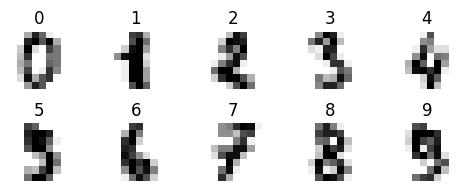

Siffra 0: 178
Siffra 1: 182
Siffra 2: 177
Siffra 3: 183
Siffra 4: 181
Siffra 5: 182
Siffra 6: 181
Siffra 7: 179
Siffra 8: 174
Siffra 9: 180


In [2]:
digits = load_digits()

# DF i utforskningssyfte
df = pd.DataFrame(np.column_stack([digits['data'],digits['target']]), columns=digits['feature_names']+['target'])

df.info()
df.describe()
df.head()

# x och y är var vår arbetsdata är
x = digits['data']
y = digits['target']
images = digits['images']

# se vad vi har i x och y
print(x.shape, y.shape)

# Gör en subplot för att visualisera datan 
fig, axes = plt.subplots(2, 5, figsize=(5, 2))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(y[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

# Hur många av varje siffra har vi?
counts = np.bincount(y)
for digit, count in enumerate(counts):
    print(f"Siffra {digit}: {count}")

In [3]:
# Standardisera datan
# Pixlarna i det här datasetet är redan i samma skala, vilket egentligen gör detta steg onödigt, men vi ska ju lära oss

# Standard scaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("Medelvärde per feature:", x_scaled.mean(axis=0).round(2)[:5])
print("Std per feature (ska vara ~1):", x_scaled.std(axis=0).round(2)[:5])
print("Verifiera form:", x_scaled.shape)
print("print x_scaled", x_scaled)

# Inför streamlit, kanske även kan göra en variant med MinMaxScaler och en knapp




Medelvärde per feature: [ 0. -0. -0. -0.  0.]
Std per feature (ska vara ~1): [0. 1. 1. 1. 1.]
Verifiera form: (1797, 64)
print x_scaled [[ 0.         -0.33501649 -0.04308102 ... -1.14664746 -0.5056698
  -0.19600752]
 [ 0.         -0.33501649 -1.09493684 ...  0.54856067 -0.5056698
  -0.19600752]
 [ 0.         -0.33501649 -1.09493684 ...  1.56568555  1.6951369
  -0.19600752]
 ...
 [ 0.         -0.33501649 -0.88456568 ... -0.12952258 -0.5056698
  -0.19600752]
 [ 0.         -0.33501649 -0.67419451 ...  0.8876023  -0.5056698
  -0.19600752]
 [ 0.         -0.33501649  1.00877481 ...  0.8876023  -0.26113572
  -0.19600752]]


Kovariansmatris från skalad data:
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          1.00055679  0.55692803 ... -0.02988686  0.02656195
  -0.04391324]
 [ 0.          0.55692803  1.00055679 ... -0.04120565  0.07263924
   0.08256908]
 ...
 [ 0.         -0.02988686 -0.04120565 ...  1.00055679  0.64868875
   0.26213704]
 [ 0.          0.02656195  0.07263924 ...  0.64868875  1.00055679
   0.62077355]
 [ 0.         -0.04391324  0.08256908 ...  0.26213704  0.62077355
   1.00055679]]


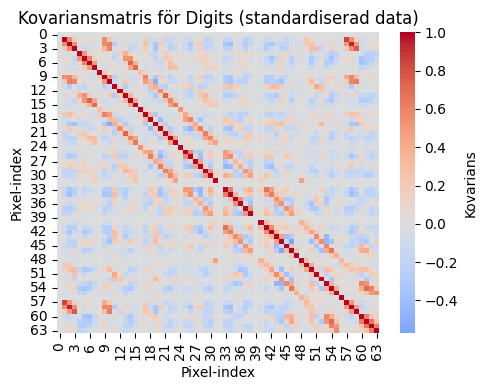

Antal egenvärden: 64
Egenvektorer shape: (64, 64)

De 10 största egenvärdena:
[7.345 5.835 5.154 3.966 2.966 2.572 2.406 2.069 1.83  1.79 ]

De 5 minsta egenvärdena:
[0.06329  0.050374 0.       0.       0.      ]


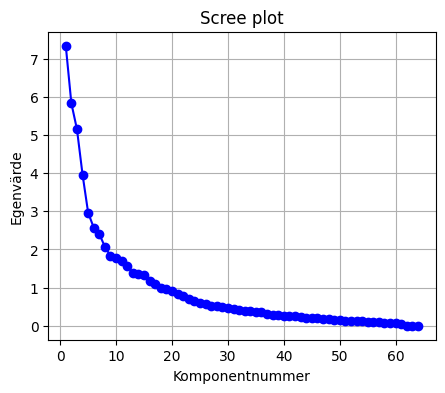

In [4]:
# Kovariansmatris
cov_matrix = np.cov(x_scaled, rowvar=False)
print("Kovariansmatris från skalad data:")
print(cov_matrix)

# Heatmap, sanity check. Vi ser att varje pixel har perfekt korrelation med sig själv. Om diagonalen inte är röd så är något fel
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cov_matrix, cmap='coolwarm', center=0, ax=ax, 
            cbar_kws={'label': 'Kovarians'})
ax.set_title("Kovariansmatris för Digits (standardiserad data)")
ax.set_xlabel("Pixel-index")
ax.set_ylabel("Pixel-index")
plt.tight_layout()
plt.show()

# Egenvärden och egenvektorer
# Hitta egenvärden och egenvektorer
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh returnerar i stigande ordning - vi vill ha fallande (störst först)
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Antal egenvärden:", len(eigenvalues))
print("Egenvektorer shape:", eigenvectors.shape)

# Värden per huvudkomponent
print("\nDe 10 största egenvärdena:")
print(eigenvalues[:10].round(3))
print("\nDe 5 minsta egenvärdena:")
print(eigenvalues[-5:].round(6))


# Screeplot
plt.figure(figsize=(5, 4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='b')
plt.title('Scree plot')
plt.xlabel('Komponentnummer')
plt.ylabel('Egenvärde')
plt.grid(True)
plt.show()

Den röda diagonalen (värde = 1.0)
Varje pixel har perfekt korrelation med sig själv. Det är en sanity check — är diagonalen inte röd, då har något gått fel.
2. De svaga diagonala linjerna parallellt med huvuddiagonalen
Ser du de rödaktiga linjerna som går snett parallellt med mitten, med ett avstånd på ungefär 8 pixlar? Det är inte en slump — det är pixlar som ligger rakt under varandra i bilden.
Kom ihåg: pixlarna är indexerade rad för rad. Pixel 0 är (rad 0, kol 0), pixel 8 är (rad 1, kol 0), pixel 16 är (rad 2, kol 0) osv. Så pixel 0 och pixel 8 är grannar vertikalt i själva bilden. När du ser bläck på en rad är det sannolikt bläck på raden under också → positiv korrelation.
3. De blockstrukturerade rutorna
Du ser tydligt 8 stycken 8×8-block längs diagonalen. Varje block motsvarar en rad av pixlar i bilden. Inom en rad är pixlar som ligger bredvid varandra korrelerade (pixel 0 och pixel 1 är horisontella grannar).
4. De mörka vertikala/horisontella strecken på position 0, 7, 8, 15, 16…
Titta längst till vänster och högst upp — det finns rader och kolumner som är helt vita/neutrala. Det är dina hörnpixlar (kanterna av bilden) som nästan alltid är 0. De har extremt låg varians och därmed låg korrelation med allt annat. Det här är samma pixlar som kan orsaka NaN-problem.
5. De blå områdena (negativa korrelationer)
Kolla nedre högra hörnet och några spridda blåa fält. När en pixel i mitten har bläck (där siffran är) är pixlar längre ut mot kanten ofta tomma → anti-korrelation. Det här är faktiskt PCA:s bästa vän — negativa korrelationer betyder att pixlarna bär redundant information som PCA kan komprimera.


Egenvärden och egenvektorer
Ett värde motsvarar en huvudkomponent (principal component), PC1, PC2, PC3 osv.

Tre egenvärden är exakt 0. Vad betyder det?
Ett egenvärde på 0 betyder att det finns en riktning i datan där det inte finns någon varians alls. Alla datapunkter ligger på exakt samma värde längs den axeln.
Och det är precis vad som händer i Digits: hörnpixlarna är alltid 0. Det är de konstanta features vi pratat om tidigare. När du har features som aldrig varierar blir kovariansmatrisen rank-deficient — den har inte full rang, vilket resulterar i noll-egenvärden.


Screeplotten ger oss en bild där det är rätt svårt att avgöra vart armbågen är. Ofta behåller man väl sådant med ett högre medelvärde än 1, vilket innebär att uppemot 20 huvudkomponenter är av intresse.

In [5]:
# PCA, projicera datan på komponenterna (via sklearn)
pca = PCA()
x_pca = pca.fit_transform(x_scaled)


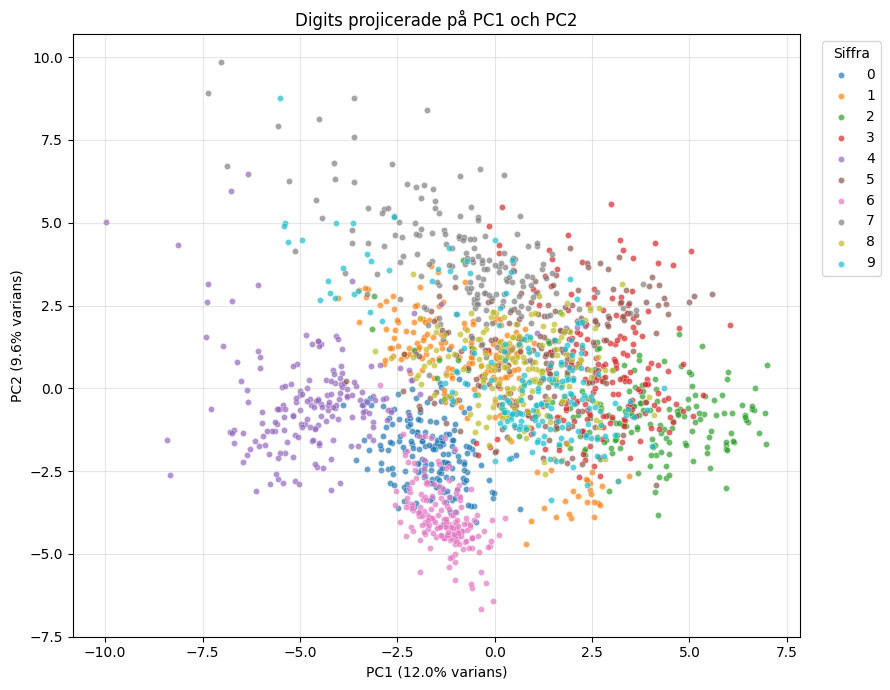

In [6]:
# Projektion av data på valda komponenter

# Beräkna varians-ratio (behövs för axeletiketterna)
variance_ratio = eigenvalues / eigenvalues.sum()

plt.figure(figsize=(9, 7))

for i in range(10):  # 10 klasser (siffrorna 0-9)
    mask = (y == i)
    plt.scatter(
        x_pca[mask, 0], x_pca[mask, 1],
        label=str(i),
        alpha=0.7, s=20, edgecolors='w', linewidth=0.3
    )

plt.xlabel(f'PC1 ({variance_ratio[0]:.1%} varians)')
plt.ylabel(f'PC2 ({variance_ratio[1]:.1%} varians)')
plt.title('Digits projicerade på PC1 och PC2')
plt.legend(title='Siffra', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Då vi har stort bidrag av många huvudkomponenter kanske PC1 och PC2 inte räcker, vi kanske behöver plotta fler huvudkomponenter.

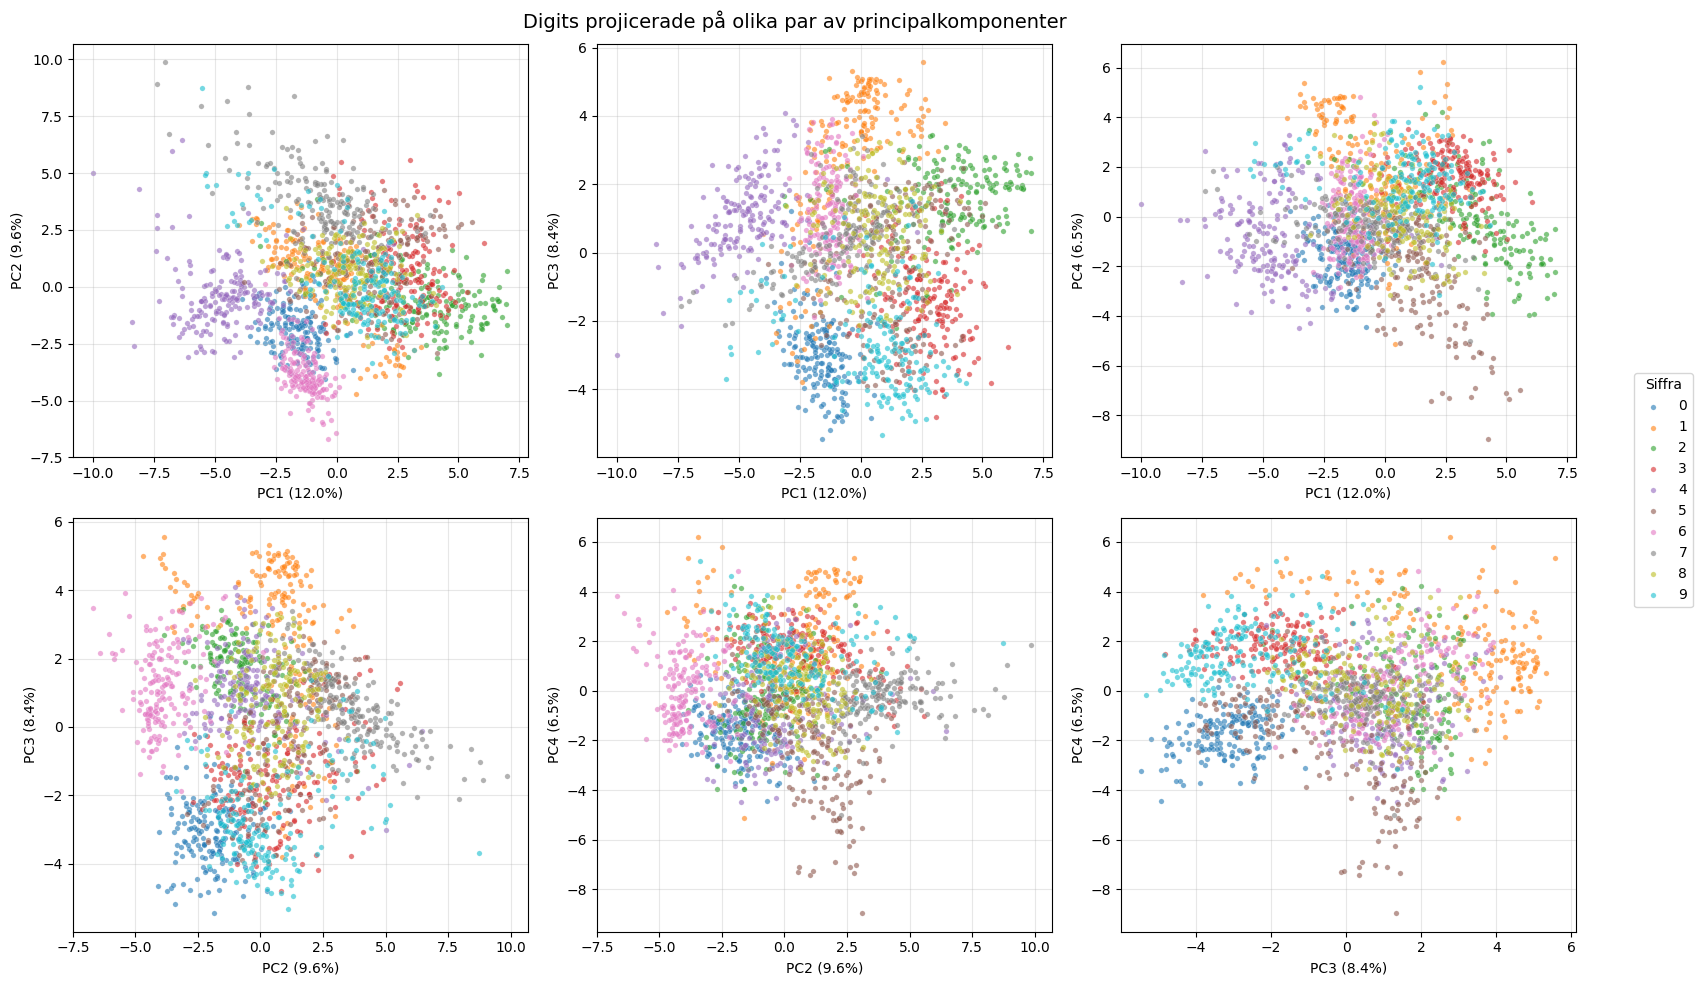

In [7]:
# Här kör vi en pairplot och plottar flera huvudkomponenter mot varandra

#Beräkna variance_ratio om den inte finns
variance_ratio = eigenvalues / eigenvalues.sum()

# Vilka par ska vi plotta?
pairs = [(0, 1), (0, 2), (0, 3), 
         (1, 2), (1, 3), (2, 3)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (pc_x, pc_y) in zip(axes.flat, pairs):
    for i in range(10):
        mask = (y == i)
        ax.scatter(
            x_pca[mask, pc_x], x_pca[mask, pc_y],
            label=str(i), alpha=0.6, s=15, 
            edgecolors='w', linewidth=0.2
        )
    ax.set_xlabel(f'PC{pc_x+1} ({variance_ratio[pc_x]:.1%})')
    ax.set_ylabel(f'PC{pc_y+1} ({variance_ratio[pc_y]:.1%})')
    ax.grid(True, alpha=0.3)

# En gemensam legend utanför plotten
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Siffra', 
           bbox_to_anchor=(1.02, 0.5), loc='center left')

plt.suptitle('Digits projicerade på olika par av principalkomponenter', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Plotly för interaktiv karta, vi kan visualisera upp till tredje huvudkomponenten med en 3d-plot.


# Skapa en DataFrame för plotly
df_3d = pd.DataFrame({
    'PC1': x_pca[:, 0],
    'PC2': x_pca[:, 1],
    'PC3': x_pca[:, 2],
    'Siffra': y.astype(str)  # string så plotly behandlar det kategoriskt
})

fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Siffra',
    color_discrete_sequence=px.colors.qualitative.T10,
    opacity=0.7,
    title=f'Digits i 3D-PCA ({variance_ratio[:3].sum():.1%} varians totalt)'
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(
        xaxis_title=f'PC1 ({variance_ratio[0]:.1%})',
        yaxis_title=f'PC2 ({variance_ratio[1]:.1%})',
        zaxis_title=f'PC3 ({variance_ratio[2]:.1%})'
    ),
    width=900,
    height=700
)

fig.show(renderer="browser")

In [9]:
# UMAP för att få med flera huvudkomponenter! Det är här vi verkligen börjar se tydliga grupperingar!

# Använd de första 20 PCA-komponenterna (behåller mycket info, tar bort brus)
x_pca_20 = x_pca[:, :20]
print(f"Använder {x_pca_20.shape[1]} komponenter som fångar {variance_ratio[:20].sum():.1%}")

# UMAP på 20 PCA-komponenter
reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
x_umap = reducer.fit_transform(x_pca_20)

df_umap = pd.DataFrame({
    'UMAP1': x_umap[:, 0],
    'UMAP2': x_umap[:, 1],
    'Siffra': y.astype(str)
})

fig = px.scatter(
    df_umap, x='UMAP1', y='UMAP2', color='Siffra',
    color_discrete_sequence=px.colors.qualitative.T10,
    opacity=0.7,
    title='UMAP på 20 PCA-komponenter'
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(width=900, height=700)
fig.show(renderer="browser")

Använder 20 komponenter som fångar 79.3%


C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
